# Multi-layer perceptron from scratch

:::{important}
This demo presents a from-scratch implementation of a multi-layer perceptron (MLP), also known as a fully connected neural network. The fundamental concepts are introduced and derived step by step—including neuron operations, forward propagation, and backpropagation. Each concept is accompanied by a Python script implemented with [JAX](https://docs.jax.dev/en/latest/). 
:::

The propagation and backpropagation of the gradient is what truly made neural networks so powerful and triggered their massive use around the world. Without it, optimizing the parameters would have been impossible. 

:::{seealso}
It was popularized by David Rumelhart, Ronald Williams and Geoffrey Hinton in 1986 in a groundbreaking article @rumelhart1986learning. Using a forward pass (propagation), and a backward pass (backpropagation), the authors introduced an efficient technique to automatically compute the gradient and train multi-layer neural networks called "automatic differentiation". 
:::


### Neurons
Neural networks are composed of neurons, also called perceptrons. To describe how a neuron computes its outputs, let us define two vectors $\mathbf{x}_1, \mathbf{x}_2 \in \mathbb{R}^n$, where $n \geq 1$. Let $w_1, w_2, b \in \mathbb{R}$. The transformation performed by a single neuron is given by
$$
\mathbf{a} = \phi\Big( w_1 \mathbf{x}_1 + w_2 \mathbf{x}_2 + b \Big) \in \mathbb{R}^{n},
$$
where $\phi$ is an activation function applied element-wise and where
$$
\mathbf{z} = w_1 \mathbf{x}_1 + w_2 \mathbf{x}_2 + b \in \mathbb{R}^n,
$$
is the linear or pre-activation part.

By noting $\mathbf{X} = \begin{bmatrix} \mathbf{x}_1 & \mathbf{x}_2 \end{bmatrix} \in \mathbb{R}^{n \times 2}$, and 
$\mathbf{w} = \begin{bmatrix} w_1 & w_2 \end{bmatrix} \in \mathbb{R}^{1 \times 2}$, this can be written more concisely:

$$
\mathbf{a} = \phi\big( \mathbf{X} {\mathbf{w}}^\top + b \big) \in \mathbb{R}^{n}.
$$

For example, the schematic of a neuron taking two input vectors $\mathbf{x}_1, \mathbf{x}_2 \in \mathbb{R}^n$ is illustrated in Figure 1:

<div style="text-align: center;">
  <img src="Images/neuron_utilidor_v2.png" width="65%">
  <figcaption><em>Figure 1: Neuron</em></figcaption>
</div>

The above expression can be generalized to any dimension $m \geq 1$, such that $\mathbf{X} \in \mathbb{R}^{n \times m}$ and, for a single neuron, $\mathbf{w} \in \mathbb{R}^{1 \times m}$:

$$
\mathbf{X} = 
\begin{bmatrix}
x_{11} & x_{12} & \dots & x_{1m} \\
x_{21} & x_{22} & \dots & x_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
x_{n1} & x_{n2} & \dots & x_{nm}
\end{bmatrix} 
\quad
\text{and}
\quad
\mathbf{w} = 
\begin{bmatrix} w_1 & w_2 & \dots & w_m \end{bmatrix} 
$$

You may wonder at this point the role of activation functions. Activation functions introduce the non-linear behavior of the model. One may particularly mention: 

- **ReLU**
$$
\mathrm{ReLU}(x) =
\begin{cases}
0 & \text{if } x \le 0 \\
x & \text{if } x > 0
\end{cases}
$$

- **Leaky ReLU** (with $\alpha > 0$)
$$
\mathrm{LeakyReLU}(x) =
\begin{cases}
\alpha x & \text{if } x \le 0 \\
x & \text{if } x > 0
\end{cases}
$$

- **Sigmoid**
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

- **Tanh**
$$
\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
$$

<div style="text-align: center;">
  <img src="Images/activations.png" width="55%">
  <figcaption><em>Figure 2: Some usual activation functions</em></figcaption>
</div>


### Propagation

#### Derivations

In a neural network, neurons are organized into hidden-layers. When the neurons of a given hidden layer are connected to all the neurons of the next hidden layer, the neural network is said to be "fully conected" or "dense". The more hidden layers, the deeper the network. 

:::{note}
A neural network is considered deep when it has more than one hidden layer. Actually, deep learning derived its name from deep neural networks.
:::

To understand the propagation inside a dense neural network (forward pass), let us take the example of neural netwrok made of two hidden layers, the first one composed of three neurons et the second of four neurons. The network takes two input features $\mathbf{x}_1, \mathbf{x}_2 \in \mathbb{R}^n$ made of $n$ examples each, such that:

$$
\mathbf{X} = 
\begin{bmatrix}
\mathbf{x}_1 & \mathbf{x}_2 
\end{bmatrix}
=\begin{bmatrix}
x_{11} & x_{12}  \\
x_{21} & x_{22}  \\
\vdots & \vdots  \\
x_{n1} & x_{n2} 
\end{bmatrix} 
\in \mathbb{R}^{n\times2}
$$

and outputs two variables $\mathbf{y}_1, \mathbf{y}_2 \in \mathbb{R}^n$, such that: 

$$
\mathbf{Y} = 
\begin{bmatrix}
\mathbf{y}_1 & \mathbf{y}_2 
\end{bmatrix}
\in \mathbb{R}^{n\times2}
$$


The network is illustrated in Figure 3.

<div style="text-align: center;">
  <img src="Images/neural_network_utilidor_v3.png" width="65%">
  <figcaption><em>Figure 3: Exampe of a dense neural network </em></figcaption>
</div>

Let us focus on the outputs of the first hidden layer. 

We note $\mathbf{z}_1^{(1)}, \mathbf{z}_2^{(1)}, \mathbf{z}_3^{(1)}$ the outputs respectively of neuron 1, 2 and 3 before activation, $\mathbf{a}_1^{(1)}, \mathbf{a}_2^{(1)}, \mathbf{a}_3^{(1)}$ the outputs respectively of neuron 1, 2 and 3 after activation, $\mathbf{W}^{(1)} \in \mathbb{R}^{3\times2}$ the matrix containing the weights such that:

$$
\mathbf{W}^{(1)} =
\begin{bmatrix}
\mathbf{w}_{1}^{(1)}  \\
\mathbf{w}_{2}^{(1)}  \\
\mathbf{w}_{3}^{(1)}  \\
\end{bmatrix} =
\begin{bmatrix}
w_{11}^{(1)} & w_{12}^{(1)}  \\
w_{21}^{(1)} & w_{22}^{(1)}  \\
w_{31}^{(1)} & w_{32}^{(1)}  \\
\end{bmatrix} 
$$

with: $\mathbf{w}_1 = \begin{bmatrix} w_{11}^{(1)} & w_{12}^{(1)} \end{bmatrix}$, $\mathbf{w}_2 = \begin{bmatrix} w_{21}^{(1)} & w_{22}^{(1)} \end{bmatrix}$ and $\mathbf{w}_3 = \begin{bmatrix} w_{31}^{(1)} & w_{32}^{(1)} \end{bmatrix}$ being line vectors $\in \mathbb{R}^{1 \times 2}$, $b_1, b_2, b_3 \in \mathbb{R}$, the biases respectively of neurons 1, 2 and 3 and $\phi_1^{(1)}, \phi_2^{(1)}, \phi_3^{(1)}$, the activation functions respectively of neurons 1, 2 and 3. One gets:

$$
\left \lbrace
\begin{align}
\mathbf{z}_1^{(1)} & = \mathbf{X}\mathbf{w}_1^T + b_1 \in \mathbb{R}^n \\
\mathbf{z}_2^{(1)} & = \mathbf{X}\mathbf{w}_2^T + b_2 \in \mathbb{R}^n \\
\mathbf{z}_3^{(1)} & = \mathbf{X}\mathbf{w}_3^T + b_3 \in \mathbb{R}^n \\
\end{align}
\right.
$$

Then:

$$
\left \lbrace
\begin{align}
\mathbf{a}_1^{(1)} & = \phi_1^{(1)}(\mathbf{z}_1^{(1)}) \in \mathbb{R}^n\\
\mathbf{a}_2^{(1)} & = \phi_2^{(1)}(\mathbf{z}_2^{(1)}) \in \mathbb{R}^n\\
\mathbf{a}_3^{(1)} & = \phi_3^{(1)}(\mathbf{z}_3^{(1)}) \in \mathbb{R}^n\\
\end{align}
\right.
$$

For conciseness, we adopt a matrix notation to express the outputs of the entire first hidden layer:

$$
\mathbf{Z}^{(1)} = \mathbf{X}{\mathbf{W}^{(1)}}^\top + \mathbf{b}^{(1)} \in \mathbb{R}^{n \times 3}
,$$

Assuming $\phi_1^{(1)} = \phi_2^{(1)} = \phi_3^{(1)} = \phi^{(1)}$, as is commonly assumed in the scientific literature, yields:

$$
\mathbf{A}^{(1)} = \phi^{(1)}\left(\mathbf{Z}^{(1)} \right) \in \mathbb{R}^{n \times 3}
$$

The complete process is illustrated in Figure 4.

<div style="text-align: center;">
  <img src="Images/hidden_layer_1_utilidor_v3.png" width="65%">
  <figcaption><em>Figure 4: Outputs of the first hidden layer</em></figcaption>
</div>

:::{hint}
Generalizing, the inputs may have $p$ features instead of $2$, in which case  $\mathbf{X} \in \mathbb{R}^{n \times p}$, and the first hidden layer may contain $m$ neurons instead of $3$, in which case $\mathbf{W}^{(1)} \in \mathbb{R}^{m \times p}$ and $\mathbf{A}^{(1)} \in \mathbb{R}^{n \times m}$.
:::

Let's now focus on the outputs of the second hidden layer. 

Hidden layer two is made of four neurons, therefore: $\mathbf{W}^{(2)} \in \mathbb{R}^{4 \times 3}$ and $\mathbf{b}^{(2)} \in \mathbb{R}^{4}$. Using the same approach as previously described:

$$
\mathbf{Z}^{(2)} = \mathbf{A}^{(1)}{{\mathbf{W}}^{(2)}}^\top + \mathbf{b}^{(2)} \in \mathbb{R}^{n \times 4}
,$$

and 

$$
\mathbf{A}^{(2)} = \phi^{(2)}\left(\mathbf{Z}^{(2)} \right) \in \mathbb{R}^{n \times 4}
$$

One can generelize to $k$ neurons in hidden layer 2 and $m$ neurons in hidden layer 1, in which case: $\mathbf{W}^{(2)} \in \mathbb{R}^{k \times m}$ and $\mathbf{A}^{(2)} \in \mathbb{R}^{n \times k}$. 

Regarding the outputs of the output layer, $\mathbf{W}^{(o)} \in \mathbb{R}^{2 \times 4}$ and $\mathbf{b}^{(o)} \in \mathbb{R}^{2}$. One gets:

$$
\mathbf{Z}^{(o)} = \mathbf{A}^{(2)}{{\mathbf{W}}^{(o)}}^\top + \mathbf{b}^{(o)} \in \mathbb{R}^{n \times 2}
,$$

and

$$
\mathbf{Y} = \mathbf{A}^{(o)} = \phi^{(o)}\left(\mathbf{Z}^{(o)} \right) \in \mathbb{R}^{n \times 2}
$$

:::{note}
Note that the activation function in the output layer is often linear.
:::

:::{hint}
One can generelize to $l$ outputs instead of 2, in which case: $\mathbf{W}^{(o)} \in \mathbb{R}^{l \times k}$ and $\mathbf{A}^{(o)} \in \mathbb{R}^{n \times l}$. 
:::

Figure 5 illustrates computations, from the outputs of hidden layer 1, $\mathbf{A}^{(1)}$, to the final outputs $\mathbf{Y}$.

<div style="text-align: center;">
  <img src="Images/hidden_layer_2_utilidor_v3.png" width="85%">
  <figcaption><em>Figure 5: Propagation until the final outputs of the neural network</em></figcaption>
</div>

#### Implementation from scratch

In [8]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit
import matplotlib.pyplot as plt

# Fix random state
key = random.PRNGKey(42)

def init_layer_params(key, l, m):
    w_key, b_key = random.split(key)
    W = random.normal(w_key, (m, l))
    b = random.normal(b_key, (m, ))
    return W, b

def init_network_params(key, input_size, output_size, hidden_sizes):
    layer_sizes = [input_size] + hidden_sizes + [output_size]
    keys = random.split(key, len(layer_sizes))
    params = []
    for l, m, key in zip(layer_sizes[:-1], layer_sizes[1:], keys):
        W, b = init_layer_params(key, l, m)
        params.append((W, b))
    return params
    
# Activation function
def relu(x):
    return jnp.maximum(0, x)
       
# Initialize network parameters
input_size = 2
output_size = 2
hidden_sizes = [4, 3]
params = init_network_params(key, input_size, output_size, hidden_sizes)

# Propagation
def forward_pass(params, X):
    A = []
    Z = []
    A_ = X
    for (W, b) in params[:-1]:
        Z_ = jnp.dot(A_, W.T) + b
        Z.append(Z_)
        A_ = relu(Z_)
        A.append(A_)
    # Linear outputs
    W, b = params[-1]
    Z_ = jnp.dot(A_, W.T) + b
    Z.append(Z_)
    A.append(Z_)
    return A, Z

n_examples = 10
# X_dummy = random.normal(key, (n_examples, input_size))

r   = jax.random.uniform(key, (n_examples,), minval=0, maxval=1)
theta = jax.random.uniform(key, (n_examples,), minval=0, maxval=2 * jnp.pi)

X_dummy = jnp.stack([r, theta], axis=1)

A, Z = forward_pass(params, X_dummy)

print(f"Number of layers : {len(params)}")
print(f"Z shapes : {[z.shape for z in Z]}")
print(f"A shapes : {[a.shape for a in A]}")

Number of layers : 3
Z shapes : [(10, 4), (10, 3), (10, 2)]
A shapes : [(10, 4), (10, 3), (10, 2)]


### Backpropagation
#### Derivations

Let us detail backpropagation using the notations introduced in the previous section.

:::{seealso}
The propagation-backpropagation is based on the [Leibniz chain rule (1673)](https://en.wikipedia.org/wiki/Chain_rule) and allows at the end of each iteration to update the network parameters. If a variable $z$ depends on a variable $y$ which itself depends on a variable $x$, then the derivation of $z$ with respect to $x$ is expressed as:

$$
\dfrac{dz}{dx} = \dfrac{dz}{dy}\dfrac{dy}{dx}
$$
:::

Once a forward pass through the network (propagation) has been computed, the goal is to calibrate the parameters of the model (weights and biases) of each hidden layer. To tune these parameters, one has first to define a distance between the predictions of the model $\mathbf{Y}$ and actual values $\mathbf{\hat{Y}}$ that the model should obtain. This is where a loss function $\mathcal{L}$ is introduced. Many loss functions exist, a notable example is the mean-squared error (MSE), defined as:

$$
\text{MSE}(\mathbf{Y}, \hat{\mathbf{Y}}) = \frac{1}{n \times q} \| \mathbf{Y} - \hat{\mathbf{Y}} \|_F^2 = \frac{1}{n \times q} \sum_{i=1}^{n} \sum_{j=1}^{q} (Y_{ij} - \hat{Y}_{ij})^2
$$

where $\| \cdot \|_F$ is the Frobenius norm and $q$ denotes the number of ouput variables (in this example $q=2$). 

Backpropagation then efficiently computes the gradient of the loss with respect to (w.r.t.) the network parameters one layer at a time, propagating iteratively backward from the last layer. In this example, the objective is therefore to compute:

$$
\dfrac{\partial \mathcal{L}}{\partial \mathbf{W}^{(o)}} \in \mathbb{R}^{2 \times 4}, 
\dfrac{\partial \mathcal{L}}{\partial \mathbf{W}^{(2)}} \in \mathbb{R}^{4 \times 3}, 
\dfrac{\partial \mathcal{L}}{\partial \mathbf{W}^{(1)}} \in \mathbb{R}^{3 \times 2}, 
\dfrac{\partial \mathcal{L}}{\partial \mathbf{b}^{(o)}} \in \mathbb{R}^{2}, 
\dfrac{\partial \mathcal{L}}{\partial \mathbf{b}^{(2)}} \in \mathbb{R}^{4},
\dfrac{\partial \mathcal{L}}{\partial \mathbf{b}^{(1)}} \in \mathbb{R}^{3} 
$$

:::{note}
In this notation, we see that a scalar (the loss) is differentiated w.r.t a tensor. We adopt the convention that the resulting gradient has the same dimensions as the tensor. 
:::

Let's get started folks!

According to the Leibniz chain rule:

$$
\dfrac{\partial \mathcal{L}}{\partial \mathbf{W}^{(o)}} = \dfrac{\partial \mathcal{L}}{\partial \mathbf{A}^{(o)}} \dfrac{\partial \mathbf{A}^{(o)}}{\partial \mathbf{Z}^{(o)}} \dfrac{\partial \mathbf{Z}^{(o)}}{\partial \mathbf{W}^{(o)}}
$$

Since $\mathbf{A}^{(o)} = \mathbf{Y} \in \mathbb{R}^{n \times 2}$, one gets, term by term:

$$ 
\dfrac{\partial \mathcal{L}}{\partial {A}_{ij}^{(o)}} = \dfrac{1}{n}\left(Y_{ij} - \hat{Y}_{ij} \right)
$$

Therefore, in matrix notation:

$$
\dfrac{\partial \mathcal{L}}{\partial \mathbf{A}^{(o)}} = \dfrac{1}{n}\left(\mathbf{Y} - \hat{\mathbf{Y}} \right)
$$

Because $\phi^{(o)}$ is applied pointwise, each output $A_{ij}^{(o)}$ depends only on the corresponding input $Z_{ij}^{(o)}$, such that:

$$
A_{ij}^{(o)} = \phi^{(o)}(Z_{ij}^{(o)})
$$

then:

$$
\dfrac{\partial A_{ij}^{(o)}}{\partial Z_{kl}^{(o)}} = 
\begin{cases}
\phi^{(o)^\prime}(Z_{kl}^{(o)}) & \text{if } k=i \text{ and } l=j \\
0 & \text{otherwise}
\end{cases}
$$

therefore:

$$
\begin{align}
\dfrac{\partial L}{\partial Z_{ij}^{(o)}} & = \sum_{k=1}^{n} \sum_{l=1}^{2} \dfrac{\partial \mathcal{L}}{\partial A_{kl}^{(o)}} \dfrac{\partial A_{kl}^{(o)}}{\partial Z_{ij}^{(o)}} \\
& = \dfrac{\partial \mathcal{L}}{\partial A_{ij}^{(o)}} \dfrac{\partial A_{ij}^{(o)}}{\partial Z_{ij}^{(o)}} \\
& = \dfrac{\partial \mathcal{L}}{\partial A_{ij}^{(o)}} \phi^{(o)^\prime}(Z_{ij}^{(o)})
\end{align}
$$

In matrix notation, this is equivalent to:

$$
\boxed{
\frac{\partial \mathcal{L}}{\partial \mathbf{Z}^{(o)}} 
= \frac{\partial \mathcal{L}}{\partial \mathbf{A}^{(o)}} \odot \phi^{(o)^ \prime}(\mathbf{Z}^{(o)}) 
= \boldsymbol{\delta}^{(o)} \in \mathbb{R}^{n \times 2}
}
$$

where $\odot$ symbolizes the hadamard element-wise multiplication.


Since $\mathbf{Z}^{(o)} = \mathbf{A}^{(2)} {\mathbf{W}^{(o)}}^\top + \mathbf{b}^{(o)}$, one has, term by term:

$$
Z_{ij}^{(o)} = \sum_{k=1}^{4}A_{ik}^{(2)}W_{jk}^{(o)} + b_j^{(o)}
$$

then:

$$
\dfrac{\partial Z_{ij}^{(o)}}{\partial W_{ab}^{(o)}} = 
\begin{cases}
A_{ib}^{(2)} & \text{if } j=a \\
0 & \text{otherwise}
\end{cases}
$$

hence:

$$
\begin{align}
\dfrac{\partial \mathcal{L}}{\partial W_{ab}^{(o)}} & = \sum_{i=1}^{n} \sum_{j=1}^{2} \dfrac{\partial \mathcal{L}}{\partial Z_{ij}^{(o)}} \dfrac{\partial Z_{ij}^{(o)}}{\partial W_{ab}^{(o)}} \\
& = \sum_{i=1}^{n} \underbrace{\dfrac{\partial \mathcal{L}}{\partial A_{ia}^{(o)}} \phi^{(o)^\prime}(Z_{ia}^{(o)})}_{\displaystyle \delta_{ia}^{(o)}} A_{ib}^{(2)} \\
& = \sum_{i=1}^{n} \delta_{ia}^{(o)} A_{ib}^{(2)}
\end{align}
$$

In matrix notation, this result is equivalent to:

$$
\boxed{
\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(o)}} = {\boldsymbol{\delta}^{(o)}}^\top \mathbf{A}^{(2)} 
}
$$


Now, `hidden layer two!`

One aims to compute $\dfrac{\partial \mathcal{L}}{\partial \mathbf{W}^{(2)}}$. According to the Leibniz chain rule:

$$
\dfrac{\partial \mathcal{L}}{\partial \mathbf{W}^{(2)}} = \dfrac{\partial \mathcal{L}}{\partial \mathbf{Z}^{(o)}} \dfrac{\partial \mathbf{Z}^{(o)}}{\partial \mathbf{Z}^{(2)}} \dfrac{\partial \mathbf{Z}^{(2)}}{\partial \mathbf{W}^{(2)}}\\
$$

we know that:

$$
\dfrac{\partial \mathcal{L}}{\partial Z_{ij}^{(o)}} = \delta_{ij}^{(o)}
$$

and 

$$
\begin{align}
\mathbf{Z}^{(o)} & = \phi^{(2)}\left(\mathbf{Z}^{(2)}\right){{\mathbf{W}}^{(o)}}^\top + \mathbf{b}^{(o)} \in \mathbb{R}^{n \times 2} \\ 
\end{align}
$$

then:

$$
\begin{align}
Z_{kl}^{(o)} & = \sum_{r=1}^{4} \phi^{(2)}\left(Z_{kr}^{(2)}\right)W_{lr}^{(o)} + b_l^{(o)}
\end{align}
$$

hence:

$$
\dfrac{\partial Z_{kl}^{(o)}}{\partial Z_{ij}^{(2)}} = 
\begin{cases}
\phi^{(2)^\prime}\left(Z_{ij}^{(2)}\right) & \text{if } k=i \\
0 & \text{otherwise}
\end{cases}
$$

Therefore:

$$
\begin{align}
\dfrac{\partial \mathcal{L}}{\partial Z_{ij}^{(o)}} & = \sum_{k=1}^{n} \sum_{l=1}^{p} \dfrac{\partial \mathcal{L}}{\partial Z_{kl}^{(o)}} \dfrac{Z_{kl}^{(o)}}{\partial Z_{ij}^{(2)}} \quad \text{zero for } k \neq i \\ 
& = \sum_{l=1}^{p} \dfrac{\partial \mathcal{L}}{\partial Z_{kl}^{(o)}} W_{lj}^{(o)} \phi^{(2)^\prime}\left(Z_{ij}^{(2)}\right) \\
& = \sum_{l=1}^{p} \delta_{il}^{(o)} W_{lj}^{(o)} \phi^{(2)^\prime}\left(Z_{ij}^{(2)}\right)
\end{align}
$$

which is equivalent in matrix notation to:

$$
\boxed{
\frac{\partial \mathcal{L}}{\partial \mathbf{Z}^{(2)}} = {\boldsymbol{\delta}^{(o)}} \mathbf{W}^{(o)} \odot \phi^{(2)^\prime}\left(\mathbf{Z}^{(2)}\right) \in \mathbb{R}^{n \times 4}
}
$$

And:

$$
\mathbf{Z}^{(2)} = \mathbf{A}^{(1)}{{\mathbf{W}}^{(2)}}^\top + \mathbf{b}^{(2)} \in \mathbb{R}^{n \times 4} \\ 
$$

then:

$$
Z_{ij}^{(2)} = \sum_{k=1}^{4} A_{ik}^{(1)} W_{jk}^{(2)} + b_j^{(2)}
$$

hence:

$$
\dfrac{\partial Z_{ij}^{(2)}}{\partial W_{ab}^{(2)}} = 
\begin{cases}
A_{ib}^{(1)} & \text{if } j=a \\
0 & \text{otherwise}
\end{cases}
$$

Thus:

$$
\begin{align}
\dfrac{\partial \mathcal{L}}{\partial W_{ab}^{(2)}} & = \sum_{i=1}^{n} \underbrace{\sum_{l=1}^{p} \delta_{il}^{(o)} W_{la}^{(o)} \phi^{(2)^\prime}\left(Z_{ia}^{(2)}\right)}_{\displaystyle \delta_{ia}^{(2)}} A_{ib}^{(1)} \\ 
& = \sum_{i=1}^{n} \delta_{ia}^{(2)} A_{ib}^{(1)}
\end{align}
$$

One recognizes the matrix product:

$$ 
\boxed{
\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(2)}} = {\boldsymbol{\delta}^{(2)}}^\top \mathbf{A}^{(1)} 
}
$$

with:

$$
\boldsymbol{\delta}^{(2)} = \boldsymbol{\delta}^{(o)} \mathbf{W}^{(o)} \odot \phi^{(2)^\prime}\left(\mathbf{Z}^{(2)}\right)
$$

Applying the same reasoning recursively yields:

$$ 
\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(1)}} = {\boldsymbol{\delta}^{(1)}}^\top \mathbf{X}
$$

with:

$$
\boldsymbol{\delta}^{(1)} = \boldsymbol{\delta}^{(2)} \mathbf{W}^{(2)} \odot \phi^{(1)^\prime}\left(\mathbf{Z}^{(1)}\right)
$$

#### Implementation from scratch

In [11]:
def relu_prime(x):
    return jnp.where(x > 0, 1.0, 0.0)

def mse(params, X, Y_true):
    A, Z = forward_pass(params, X)
    Y_pred = A[-1]
    return jnp.mean((Y_pred - Y_true)**2)
    
def compute_gradients(A, Z, params, X, Y_true):
    Ao, Zo = A[-1], Z[-1]
    A2, Z2 = A[-2], Z[-2]
    A1, Z1 = A[-3], Z[-3]

    Wo, bo = params[-1]
    W2, b2 = params[-2]
    W1, b1 = params[-3]
    
    # Output layer
    dL_dAo = 2 / Ao.shape[0] / Ao.shape[1] * (Ao - Y_true)
    delta_o = dL_dAo 
    dWo = jnp.dot(delta_o.T, A2)
    dbo = jnp.dot(delta_o.T, jnp.ones((Ao.shape[0], )))

    # Hidden layer 2
    delta_2 = jnp.dot(delta_o, Wo) * relu_prime(Z2)
    dW2 = jnp.dot(delta_2.T, A1)
    db2 = jnp.dot(delta_2.T, jnp.ones((A2.shape[0], )))

    # Hidden layer 1
    delta_1 = jnp.dot(delta_2, W2) * relu_prime(Z1)
    dW1 = jnp.dot(delta_1.T, X)
    db1 = jnp.dot(delta_1.T, jnp.ones((A1.shape[0], )))

    return [(dW1, db1), (dW2, db2), (dWo, dbo)]
    
# Y_dummy = random.normal(key, (n_examples, output_size))  
Y_dummy = jnp.stack([r * jnp.cos(theta), r * jnp.sin(theta)], axis=1)
grads = compute_gradients(A, Z, params, X_dummy, Y_dummy)

for i, (W, b) in enumerate(grads):
    print(f"Layer {i+1}")
    print(f"dW shapes : {W.shape}")
    print(f"db shapes : {b.shape}")
    
# Compare with jax autodiff
auto_grads = jax.grad(mse)(params, X_dummy, Y_dummy)
for (dW_man, db_man), (dW_auto, db_auto) in zip(grads, auto_grads):
    print("W close :", jnp.allclose(dW_man, dW_auto, atol=1e-6))
    print("b close :", jnp.allclose(db_man.squeeze(), db_auto, atol=1e-6))

Layer 1
dW shapes : (4, 2)
db shapes : (4,)
Layer 2
dW shapes : (3, 4)
db shapes : (3,)
Layer 3
dW shapes : (2, 3)
db shapes : (2,)
W close : True
b close : True
W close : True
b close : True
W close : True
b close : True


### Training

#### From scratch
Once the gradients have been backpropagated, the parameters of the neural network can be updated. For instance, using the gradient descent algorithm:

$$
\left \lbrace
\begin{align}
\mathbf{W}^{(o)} & \leftarrow \mathbf{W}^{(o)}  -  \eta \dfrac{\partial \mathcal{L}}{\partial \mathbf{W}^{(o)}} \\ 
\mathbf{W}^{(2)} & \leftarrow \mathbf{W}^{(2)}  - \eta \dfrac{\partial \mathcal{L}}{\partial \mathbf{W}^{(2)}} \\
\mathbf{W}^{(1)} & \leftarrow \mathbf{W}^{(1)}  - \eta \dfrac{\partial \mathcal{L}}{\partial \mathbf{W}^{(1)}}
\end{align}
\right.
$$

and

$$
\left \lbrace
\begin{align}
\mathbf{b}^{(o)} & \leftarrow \mathbf{b}^{(o)}  -  \eta \dfrac{\partial \mathcal{L}}{\partial \mathbf{b}^{(o)}} \\ 
\mathbf{b}^{(2)} & \leftarrow \mathbf{b}^{(2)}  - \eta \dfrac{\partial \mathcal{L}}{\partial \mathbf{b}^{(2)}} \\
\mathbf{b}^{(1)} & \leftarrow \mathbf{b}^{(1)}  - \eta \dfrac{\partial \mathcal{L}}{\partial \mathbf{b}^{(1)}}
\end{align}
\right.
$$

where $\eta$ denotes the learning rate, that is, the step size in the direction that reduces the loss.

Training is typically repeated for several epochs. One epoch is completed when a forward pass and a backward pass have been computed and the model has been updated accordingly. 

:::{seealso}
A more detailed introduction about machine learning surrogate models is proposed in chapter 1 of @tristani_phd. 
:::

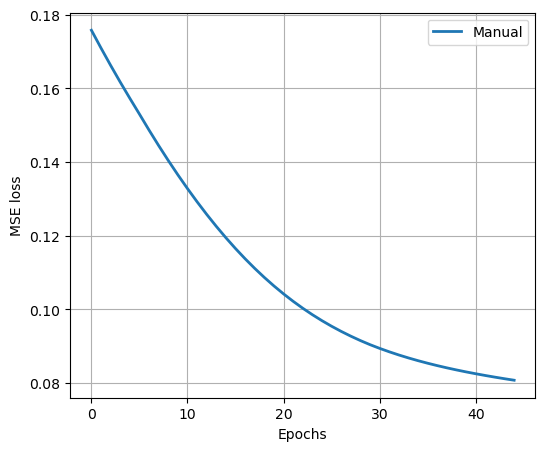

In [18]:
# Gradient descent
def update_params(params, grads, lr=1e-2):
    new_params = []
    for (W, b), (dW, db) in zip(params, grads):
        W = W - lr * dW
        b = b - lr * db  
        new_params.append((W,b))
    return new_params

def training(n_epochs, params, X, Y_true):
    loss_history = []
    for epoch in range(n_epochs):
        A, Z = forward_pass(params, X)
        loss = mse(params, X, Y_true)
        loss_history.append(loss)
        grads = compute_gradients(A, Z, params, X, Y_true)
        params = update_params(params, grads)
    return loss_history

n_epochs = 50
loss_history = training(n_epochs, params, X_dummy, Y_dummy)

plt.figure(figsize=(6,5))
plt.plot(loss_history[5:],label="Manual",linestyle="-",linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("MSE loss")
plt.grid()
plt.legend()
plt.show()

#### Using JAX predefined tools

Fortunately, in practice, one doesn't have to manually compute the gradients for backpropagation as JAX provides build-in functions to do that for us.

- **`value_and_grad`**: Returns both the value of a function and its gradient w.r.t. its inputs.

- **`jit`**: Compiles a function into a computation graph after the first call, which is then reused for faster execution.

- **`vmap`**: Vectorizes a function automatically over a batch of inputs, removing explicit loops and speeding up computations.

- **`Optax`**: A library for gradient-based optimization, offering a variety of optimizers and functions to apply updates to model parameters.

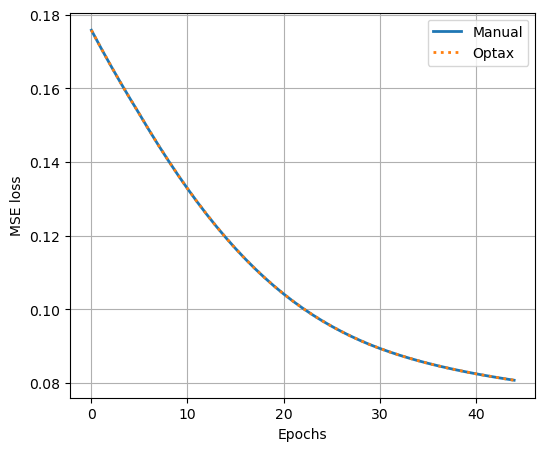

In [19]:
from jax import value_and_grad, jit, vmap
import optax
from optax import apply_updates

# Gradient descent
lr = 1e-2
optimizer = optax.sgd(lr)
opt_state = optimizer.init(params)

def forward_single(params, x):
    a = x
    for W, b in params[:-1]:
        z = jnp.dot(a, W.T) + b
        a = relu(z)
    W, b = params[-1]
    y = jnp.dot(a, W.T) + b
    return y
    
# Once can vectorize over all examples in the batch X using vmap
def mse(params, X, Y):
    forward_batch = jax.vmap(forward_single, in_axes=(None, 0))  # params is not vectorized, x is vectorized along axis 0 (lines)
    Y_pred = forward_batch(params, X)
    return jnp.mean((Y_pred - Y)**2)

@jit
def update_optax(params, opt_state, X, Y):
    loss, grads = value_and_grad(mse)(params, X, Y)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = apply_updates(params, updates)
    return params, opt_state, loss
    
def training_optax(n_epochs, params, opt_state, X, Y_true):
    loss_history = []
    for epoch in range(n_epochs):
        params, opt_state, loss = update_optax(params, opt_state, X, Y_true)
        loss_history.append(loss)
    return loss_history

loss_history_optax = training_optax(n_epochs, params, opt_state, X_dummy, Y_dummy)

plt.figure(figsize=(6,5))
plt.plot(loss_history[5:],label="Manual",linestyle="-",linewidth=2)
plt.plot(loss_history_optax[5:],label="Optax",linestyle=":",linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("MSE loss")
plt.grid()
plt.legend()
plt.show()

#### Using Equinox library

:::{note}
The [Equinox](https://docs.kidger.site/equinox/) library is particularly useful because it allows models to be defined as PyTrees, enabling seamless compatibility with JAX's core transformations such as `jit`, `grad`, and `vmap`. Unlike raw JAX, where parameter dictionaries must be explicitly passed and managed at each training step, Equinox encapsulates parameters within the model object itself. This makes the code cleaner and more intuitive, while preserving the full flexibility and performance of JAX. 
:::

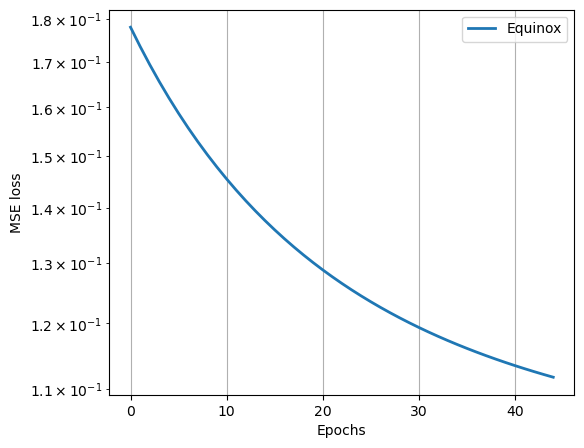

In [20]:
import jax
from jax import vmap
import optax
import equinox as eqx
from equinox import filter_value_and_grad, apply_updates, filter_jit

class MLP(eqx.Module):
    layers:list
    activation: callable = jax.nn.relu
    
    def __init__(self, in_size, out_size, hidden_sizes, key):
        keys = jax.random.split(key, len(hidden_sizes) + 1)
        self.layers = []
        
        last_size = in_size
        for h, k in zip(hidden_sizes, keys[:-1]):
            self.layers.append(eqx.nn.Linear(last_size, h, key=k))
            last_size = h
        # Output layer
        output_layer = eqx.nn.Linear(last_size, out_size, key=keys[-1])
        self.layers.append(output_layer)

    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        # Linear activation for the output
        x = self.layers[-1](x)
        return x

def loss_fn(model, X, y):
    y_pred = vmap(model)(X)
    return jnp.mean((y_pred - y)**2)

@filter_jit
def update_state(model, opt_state, X, Y_true):
    loss, grads = filter_value_and_grad(loss_fn)(model, X, Y_true)
    updates, opt_state = optimizer.update(grads, opt_state, params=model)
    new_model = apply_updates(model, updates)
    return new_model, opt_state, loss

def train(n_epochs, model, opt_state, X, Y_true):
    loss_history = []
    for epoch in range(n_epochs):
        model, opt_state, loss = update_state(model, opt_state, X, Y_true)
        loss_history.append(loss)
    return model, loss_history

# Initialize model
key = jax.random.PRNGKey(42)
model = MLP(input_size, output_size, hidden_sizes, key)
# print(model)

# Initialize optimizer
optimizer = optax.sgd(1e-2)
params = eqx.filter(model, eqx.is_array) # Filter only array-like parameters
opt_state = optimizer.init(params)

# Training
n_epochs = 50
model, loss_history_eqx = train(n_epochs, model, opt_state, X_dummy, Y_dummy)
                                                           
plt.figure(figsize=(6,5))
plt.plot(loss_history[5:],label="Manual",linestyle="-",linewidth=2)
plt.plot(loss_history_optax[5:],label="Optax",linestyle=":",linewidth=2)
plt.semilogy(loss_history_eqx[5:], label="Equinox", linestyle="-",linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("MSE loss")
plt.legend()
plt.grid()
plt.show()